In [18]:
import matplotlib.pyplot as plt
import numpy as np
from model_ranking.utils import load_h5, get_roi_slice

In [19]:
raw_data_path = "/g/kreshuk/talks/data/Rmito/test_converted.h5"

In [21]:
raw = load_h5(raw_data_path, "raw")
gt = load_h5(raw_data_path, "labels")

## E_model_Res1

In [20]:
path_pred = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Rmito_gap/consistency/P_full/E_model_Res1/norm_Normalize/none/predictions/test_converted_predictions.h5"
path_pert_pred = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Rmito_gap/consistency/P_full/E_model_Res1/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"

In [22]:
pred = load_h5(path_pred, "predictions")
patch_index = load_h5(path_pred, "patch_index")
pert_pred = load_h5(path_pert_pred, "predictions")

In [23]:
f1_score = load_h5(path_pred, "hard_f1")
consis_score = load_h5(path_pert_pred, "EI_consis")

In [24]:
f1_score.shape

(3750, 2)

In [25]:
consis_score.shape

(3750,)

In [26]:
np.nanmedian(consis_score)

0.67131275

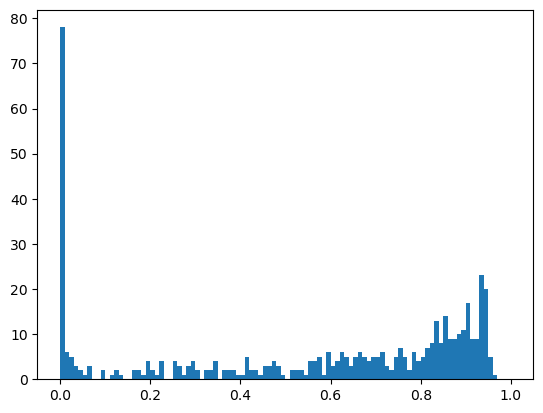

In [27]:
plt.hist(consis_score, bins=100, range=(0, 1))
plt.show()

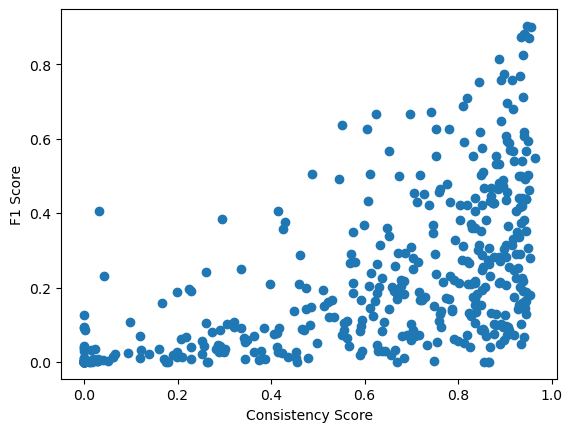

In [28]:
plt.plot(consis_score, f1_score[:, 1], "o")
plt.xlabel("Consistency Score")
plt.ylabel("F1 Score")
plt.show()

In [29]:
ids = np.where((consis_score > 0.8) & (f1_score[:, 1] <0.1))[0]
print(len(ids), "patches with consistency score < 0.4")

23 patches with consistency score < 0.4


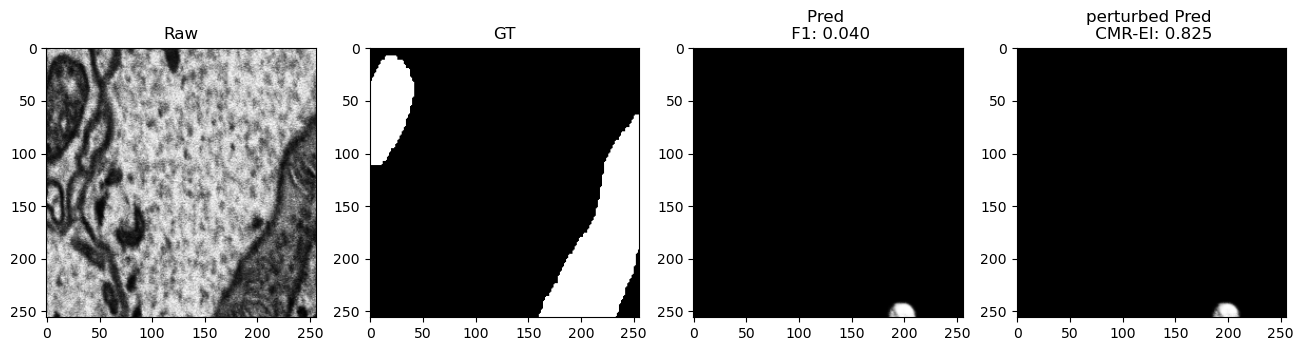

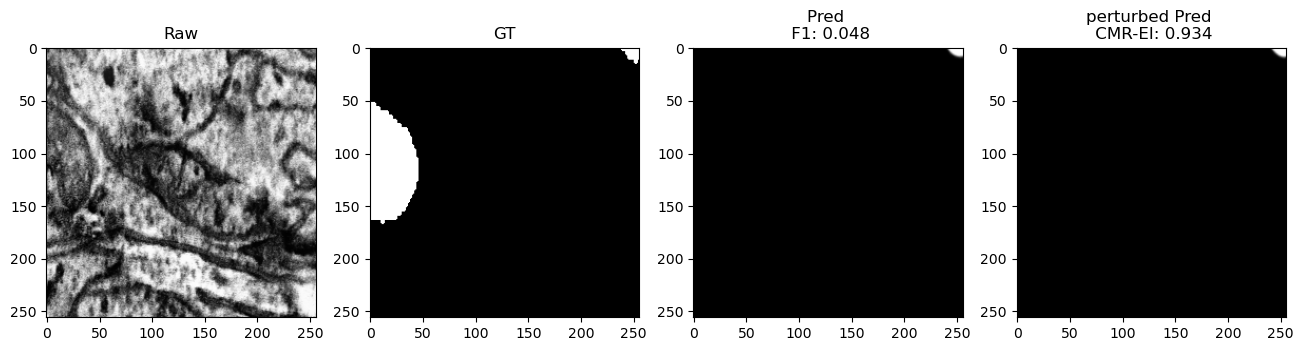

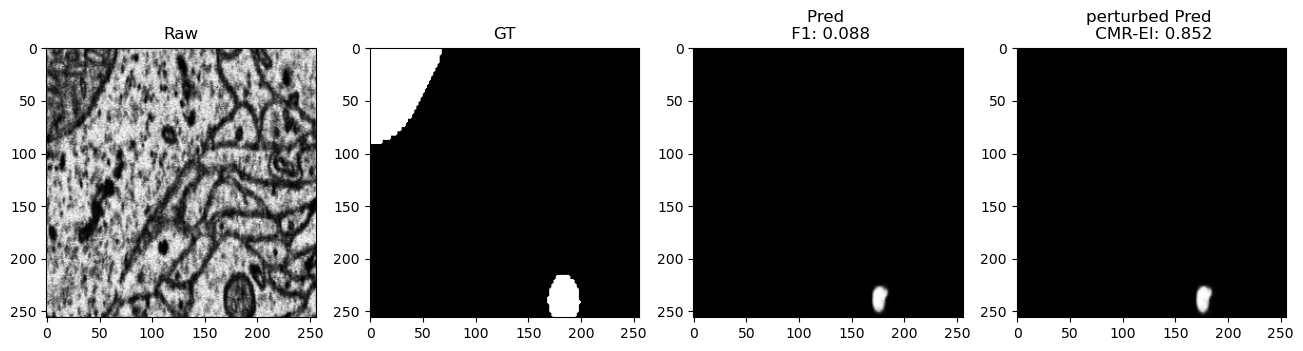

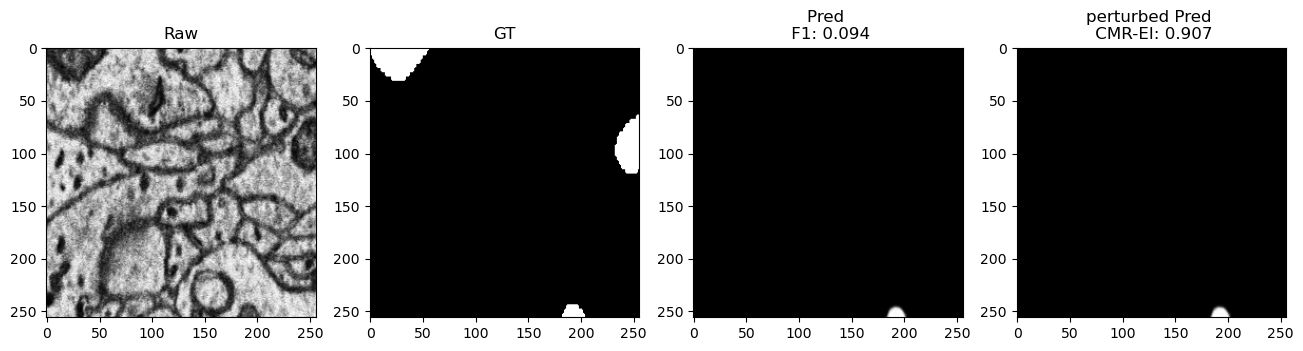

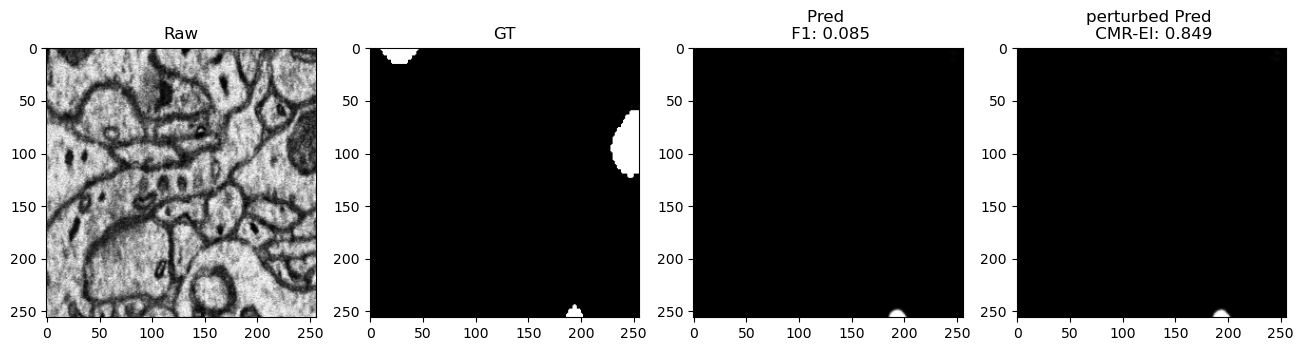

In [30]:
offset = 0
for i in ids[offset:offset + 5]:
    patch_roi = get_roi_slice(patch_index[i])
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(raw[patch_roi].squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt[patch_roi].squeeze(), cmap="gray")
    axs[1].set_title("GT")
    axs[2].imshow(pred[i].squeeze(), cmap="gray")
    axs[2].set_title(f"Pred \n F1: {f1_score[i, 1]:.3f}")
    axs[3].imshow(pert_pred[i].squeeze(), cmap="gray")
    axs[3].set_title(f"perturbed Pred \n CMR-EI: {consis_score[i]:.3f}")
    plt.show()

In [9]:
ids = (np.where(f1_score[:, 1] > 0.7) and (np.where(consis_score > 0.75) and np.where(consis_score < 0.85)))[0]

In [10]:
i = ids[0]
patch_roi = patch_index[i]
print(patch_roi)

[[  0   1]
 [  0 256]
 [  0 256]]


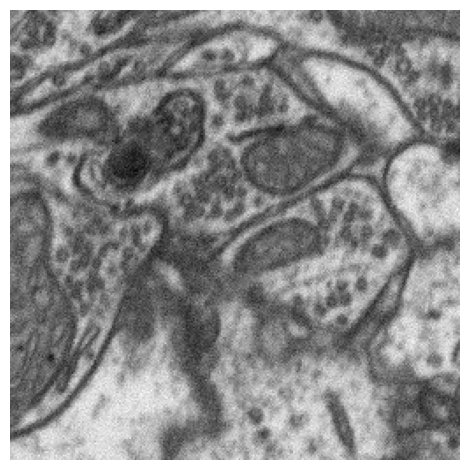

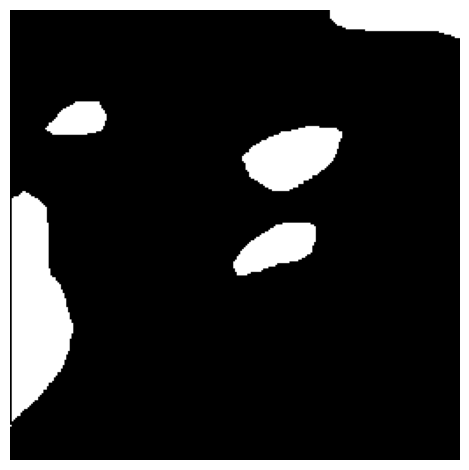

In [12]:
raw_patch = raw[get_roi_slice(patch_index[i])]
label_patch = gt[get_roi_slice(patch_index[i])]

_ = plt.imshow(raw_patch.squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_raw.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(label_patch.squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_label.png", bbox_inches="tight", pad_inches=0)
plt.show()

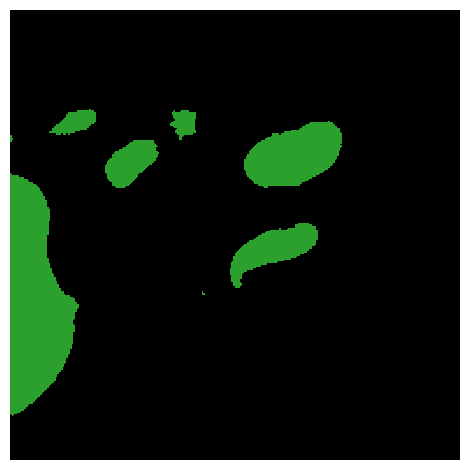

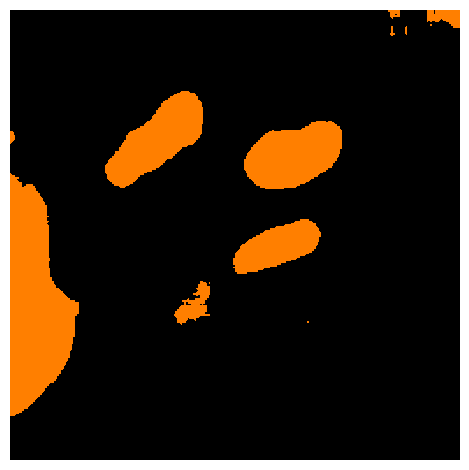

In [13]:
from matplotlib.colors import ListedColormap

hex_color1 = "#2ca02c"  # replace with your desired hex color
hex_color2 = "#ff7f00"  # replace with your desired hex color
pred_cmap = ListedColormap(["black", hex_color1])
pert_pred_cmap = ListedColormap(["black", hex_color2])

i = ids[0]
pp = (pert_pred[i] > 0.5).squeeze()
p = (pred[i] > 0.5).squeeze()

_ = plt.imshow(p.astype(int), cmap=pred_cmap, vmin=0, vmax=1)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/HtoE_Res1_pred.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(pp.astype(int), cmap=pert_pred_cmap, vmin=0, vmax=1)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/HtoE_Res1_pert_pred.png", bbox_inches="tight", pad_inches=0)
plt.show()


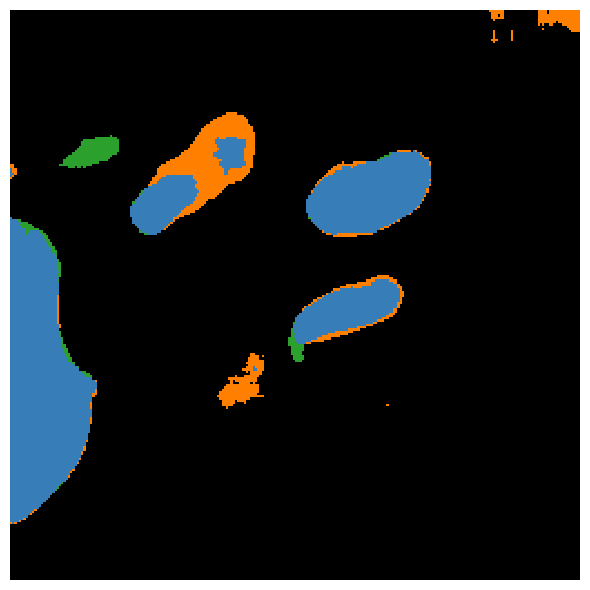

In [14]:
from matplotlib.colors import ListedColormap

hex_color3 = "#377eb8"
overlay = np.zeros_like(p, dtype=np.uint8)
overlay[(pp == 1) & (p == 0)] = 1
overlay[(p == 1) & (pp == 0)] = 2
overlay[(p == 1) & (pp == 1)] = 3

overlay_cmap = ListedColormap(["black", hex_color2, hex_color1, hex_color3])

fig, ax = plt.subplots(figsize=(6, 6))
_ = ax.imshow(overlay, cmap=overlay_cmap, vmin=0, vmax=3, interpolation="nearest")
_ = ax.axis("off")



plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/HtoE_Res1_overlay.png", bbox_inches="tight", pad_inches=0)
plt.show()
